In [184]:
import numpy as np
import os, sys, json

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import met_brewer as mb
import argparse
import diffrax as dx
import jax
import jax.numpy as jnp
from sympy import *
import ipywidgets as widgets
from pytensor.link.jax.dispatch import jax_funcify
from pymc.sampling.jax import sample_numpyro_nuts, sample_blackjax_nuts
import preliz as pz
import nutpie

sys.path.append('../')
from plotting_helper_funcs import *
from utils import *
from pymc_jax_ode import *

sys.path.append('../models/')
from MA_single_diffrax import *


jax.config.update('jax_enable_x64', True)

plt.style.use('~/.matplotlib/stylelib/custom.mplstyle')

In this notebook we explore the sensor model and the changes in phosphorylation rate that give the nonmonotonic repsonse that is observed in the data.
We answer the following questions:
1. What features of a time-dependent phosphorylation rate give rise to a nonmonotonic response in the sensor?

The sensor model will be follows:
$$
\begin{align}
{\rm AMPKAR} \xrightleftharpoons[k_{\rm dephos}]{k_{\rm phos}(t)} {\rm pAMPKAR}
\end{align}
$$
with the ODEs:
$$
\begin{align}
\frac{{\rm d}[{\rm AMPKAR}]}{{\rm d}t} &= k_{\rm dephos}[{\rm pAMPKAR}](t) - k_{\rm phos}(t)[{\rm pAMPKAR}](t) \\
\frac{{\rm d}[{\rm pAMPKAR}]}{{\rm d}t} &= -k_{\rm dephos}[{\rm pAMPKAR}](t) + k_{\rm phos}(t)[{\rm pAMPKAR}](t) \\
\end{align}
$$
Here, $k_{\rm phos}(t)$ is the phosphorylation rate, which is a function of time because it depends on a constant phosporylation rate and binding constant, and a time-varying concentration of active AMPK.

To enable exploration of the timescale of the phosphorylation we will assume that the phosphorylation rate is a function of time. We will parameterize the phosphorylation rate as follows:
$$
\begin{align}
k_{\rm phos,linear}(t) &= \theta_1*t \\
k_{\rm phos,affine}(t) &= \theta_1*t \\
k_{\rm phos,exp}(t) &= \theta_1(1 - \exp(-\theta_2*t)) 
\end{align}
$$
where $\theta_1, \theta_2, \dots,$ are parameters that can be varied to explore the timescale of the phosphorylation.

We assume that the total concentration of the sensor is constant, i.e. $[{\rm AMPKAR}] + [{\rm pAMPKAR}] = 1.0$, and that the initial condition is $[{\rm AMPKAR}](0) = 1.0$ and ${\rm total}$ and $[{\rm pAMPKAR}](0) = 0$.

Additionally, we assume that $k_{\rm dephos,nominal} = 0.001$, but this parameter can be varied as well.

##### Define models

In [264]:
def sensor_model_linear(t, y, args):
    # unpack parameters
    theta_1 = args[0]
    k_dephos = args[1]
    
    # unpack state variables
    AMPKAR_p = y
    AMPKAR = 1 - AMPKAR_p # apply conversation of mass

    k_phos_func = lambda t: theta_1*t
    k_phos_t = k_phos_func(t)
    # theta_1*t
        
    # fluxes
    J_1 = k_dephos*AMPKAR_p
    J_2 = k_phos_t*AMPKAR

    return J_2 - J_1
    

def sensor_model_affine(t, y, args):
    # unpack parameters
    theta_0 = args[0]
    theta_1 = args[1]
    k_dephos = args[2]
    
    # unpack state variables
    AMPKAR_p = y
    AMPKAR = 1 - AMPKAR_p # apply conversation of mass

    k_phos_t = theta_0 + theta_1*t
        
    # fluxes
    J_1 = k_dephos*AMPKAR_p
    J_2 = k_phos_t*AMPKAR

    return J_2 - J_1


def sensor_model_exponential(t, y, args):
    # unpack parameters
    theta_1 = args[0]
    theta_2 = args[1]
    k_dephos = args[2]
    
    # unpack state variables
    AMPKAR_p = y
    AMPKAR = 1 - AMPKAR_p # apply conversation of mass

    k_phos_t = theta_1*(1 - jnp.exp(-theta_2*t))
        
    # fluxes
    J_1 = k_dephos*AMPKAR_p
    J_2 = k_phos_t*AMPKAR

    return J_2 - J_1

@jax.jit
def solve_numerical_linear(args, t_eval):
    # initial conditions
    AMPKAR_p_0 = 0.0
    y0 = jnp.array([AMPKAR_p_0])
    # solve ODE

    sol = dx.diffeqsolve(dx.ODETerm(sensor_model_linear), dx.Kvaerno5(), 0.0, t_eval[-1], 0.01, y0,
                        args=args, saveat=dx.SaveAt(ts=t_eval),
                        stepsize_controller=dfrx.PIDController(1e-3, 1e-6), max_steps=1000000,
                        throw=False)
    
    return sol.ys

@jax.jit
def solve_numerical_affine(args, t_eval):
    # initial conditions
    AMPKAR_p_0 = 0.0
    y0 = jnp.array([AMPKAR_p_0])
    # solve ODE

    sol = dx.diffeqsolve(dx.ODETerm(sensor_model_affine), dx.Kvaerno5(), 0.0, t_eval[-1], 0.01, y0,
                        args=args, saveat=dx.SaveAt(ts=t_eval),
                        stepsize_controller=dfrx.PIDController(1e-3, 1e-6), max_steps=100000,
                        throw=False)
    
    return sol.ys

@jax.jit
def solve_numerical_exponential(args, t_eval):
    # initial conditions
    AMPKAR_p_0 = 0.0
    y0 = jnp.array([AMPKAR_p_0])
    # solve ODE

    sol = dx.diffeqsolve(dx.ODETerm(sensor_model_exponential), dx.Kvaerno5(), 0.0, t_eval[-1], 0.01, y0,
                        args=args, saveat=dx.SaveAt(ts=t_eval),
                        stepsize_controller=dfrx.PIDController(1e-3, 1e-6), max_steps=100000,
                        throw=False)
    
    return sol.ys



t_eval = np.linspace(0, 1800, 3000)

# def analytical_sol_linear(k_phos_val, k_dephos_val, t_eval):
#     """ solution with linear k_phos(t) = k_phos*t """
#     _t = symbols('t') # create sympy vars
#     _k_phos = symbols('k_phos')
#     _k_dephos = symbols('k_dephos')
#     _c_1 = symbols('c_1')

#     _f = _k_dephos + _k_phos*_t # first find the alpha(t) integral
#     _alpha_t = integrate(_f, (_t, 1, _t))

#     _f_2 = _alpha_t*_k_phos*_t # secondary function to integrate
#     # full solution as a func of integration constant
#     _sol = _c_1*exp(-_alpha_t) + exp(-_alpha_t) + integrate(_f_2, (_t, 1, _t))
#     # find the IC by applying sol(0) = 0
#     _ic_tmp = _sol.subs({_k_phos: k_phos_val, _k_dephos: k_dephos_val, _t: 0.0})
#     _c_1_sol = solve(_ic_tmp, _c_1)[0] # solve for ic
#     _sol = _sol.subs(_c_1, _c_1_sol) # apply c_1 back into solution

#     # evaluate the solution with specific values of params
#     _sol = _sol.subs({_k_phos: k_phos_val, _k_dephos: k_dephos_val})
#     # get func to evaluate
#     sol_func = lambdify(_t, _sol, 'numpy')
  
#     return sol_func(t_eval)

def plot_pAMPKAR(theta_0, theta_1_linear, theta_1_exp, theta_2, k_dephos): 
    y_linear = solve_numerical_linear([theta_1_linear, k_dephos], t_eval)
    y_affine = solve_numerical_affine([theta_0, theta_1_linear, k_dephos], t_eval)
    y_exponential = solve_numerical_exponential([theta_1_exp, theta_2, k_dephos], t_eval)

    fig, ax = plt.subplots(1,2, figsize=(8,4))
    ax[0].plot(t_eval, y_linear, 'k', label='Linear')
    ax[0].plot(t_eval, y_affine, 'b', label='Affine')
    ax[0].plot(t_eval, y_exponential, 'g', label='Exponential')
    ax[0].set_xlabel('Time (s)')
    ax[0].set_ylabel('pAMPKAR')
    ax[0].set_ylim([0,1.0])

    k_phos_t_linear = theta_1_linear*t_eval
    k_phos_affine = theta_0 + theta_1_linear*t_eval
    k_phos_t_exp = theta_1_exp*(1 - jnp.exp(-theta_2*t_eval))
    ax[1].plot(t_eval, k_phos_t_linear, 'k')
    ax[1].plot(t_eval, k_phos_affine, 'b')
    ax[1].plot(t_eval, k_phos_t_exp, 'g')
    ax[1].set_xlabel('Time (s)')
    ax[1].set_ylabel('k_phot(t)')
    ax[1].set_ylim([0,0.1])
    # ax[1].legend([f'Linear: k_phos(t) = {theta_1_linear}*t', 
    #               f'Affine: k_phos(t) = {theta_0} + {theta_1_linear}*t',
    #               f'Exponential: k_phos(t) = {theta_1_exp}(1 - exp(-{theta_2}*t))'],
    #               fontsize=8)
    ax[1].legend([f'Linear: k_phos(t) = {theta_1_linear:.3e}*t', 
                  f'Affine: k_phos(t) = {theta_0:.3e} + {theta_1_linear:.3e}*t',
                  f'Exponential: k_phos(t) = {theta_1_exp:.3e}(1 - exp(-{theta_2:.3e}*t))'],
                  fontsize=8, loc='upper left', bbox_to_anchor=(0, 1.125))
 
    plt.show()

    # plot derivatives
    fig, ax = plt.subplots(1,2, figsize=(8,4))
    y_linear_rate = sensor_model_linear(t_eval, np.squeeze(y_linear), [theta_1_linear, k_dephos])
    y_affine_rate = sensor_model_affine(t_eval, np.squeeze(y_affine), [theta_0, theta_1_linear, k_dephos])
    y_exponential_rate = sensor_model_exponential(t_eval, np.squeeze(y_exponential), [theta_1_exp, theta_2, k_dephos])

    ax[0].plot(t_eval, y_linear_rate, 'k', label='Linear')
    ax[0].plot(t_eval, np.gradient(np.squeeze(y_linear)), 'k--', label='Linear')
    ax[0].plot(t_eval, y_affine_rate, 'b', label='Affine')
    ax[0].plot(t_eval, y_exponential_rate, 'g', label='Exponential')
    ax[0].set_xlabel('Time (s)')
    ax[0].set_ylabel('d pAMPKAR(t)/dt')
    
    ax[1].plot(t_eval, np.gradient(y_linear_rate), 'k')
    ax[1].plot(t_eval, np.gradient(np.gradient(np.squeeze(y_linear))), 'k--', label='Linear')
    ax[1].plot(t_eval, np.gradient(y_affine_rate), 'b')
    ax[1].plot(t_eval, np.gradient(y_exponential_rate), 'g')
    ax[1].set_xlabel('Time (s)')
    ax[0].set_ylabel('d^2 pAMPKAR(t)/dt^2')
    # ax[1].set_ylim([0,0.1])
    # ax[1].legend([f'Linear: k_phos(t) = {theta_1_linear}*t', 
    #               f'Affine: k_phos(t) = {theta_0} + {theta_1_linear}*t',
    #               f'Exponential: k_phos(t) = {theta_1_exp}(1 - exp(-{theta_2}*t))'],
    #               fontsize=8)
    # ax[1].legend([f'Linear: k_phos(t) = {theta_1_linear:.3e}*t', 
    #               f'Affine: k_phos(t) = {theta_0:.3e} + {theta_1_linear:.3e}*t',
    #               f'Exponential: k_phos(t) = {theta_1_exp:.3e}(1 - exp(-{theta_2:.3e}*t))'],
    #               fontsize=8, loc='upper left', bbox_to_anchor=(0, 1.125))
 
    plt.show()
# y_linear = solve_numerical(sensor_model_linear, [0.01, 0.001], t_eval)

##### Simple app to simulate models with user controlled parameters

In [268]:
theta_0_slider = widgets.FloatSlider(min=0, max=1e-2, value=0, description='theta_0',
                                        step=1e-10, continous_update=True,
                                        readout_format='.14f')
theta_1_linear_slider = widgets.FloatSlider(min=0, max=1e-4, value=0, description='theta_1 - Linear',
                                      step=1e-10, continous_update=True, 
                                      readout_format='.14f')
theta_1_exp_slider = widgets.FloatSlider(min=0, max=1e-1, value=0, description='theta_1 - Exponential',
                                      step=1e-10, continous_update=True, 
                                      readout_format='.14f')
theta_2_exp_slider = widgets.FloatSlider(min=0, max=1e-2, value=0, description='theta_2 - Expoential',
                                      step=1e-10, continous_update=True, 
                                      readout_format='.14f')
k_dephos_slider = widgets.FloatSlider(min=0, max=1e-2, value=0.001, description='k_dephos',
                                      step=1e-10, continous_update=True, 
                                      readout_format='.14f')

widget = widgets.interactive(plot_pAMPKAR, theta_0=theta_0_slider, theta_1_linear=theta_1_linear_slider, theta_1_exp=theta_1_exp_slider,
                                theta_2=theta_2_exp_slider, k_dephos=k_dephos_slider)
display(widget)

interactive(children=(FloatSlider(value=0.0, description='theta_0', max=0.01, readout_format='.14f', step=1e-1…

It appears that the nonmonotonic response is due to the timescale of the phosphorylation rate of the sensor. In general if there is no initial phosphorylation rate, then we observe a sigmoidal response, if the initial phosphorylation rate is small enough, then we see also see a sigmoidal response. However, if the if the initial rate is too large, we see a nonmonotonic response. This suggests that the nonmonotonic response is due to the timescale of the phosphorylation rate. Furthermore, if the phosphorylation rate is too fast, then we still get a sigmoidal response, mathematically, but the inflection point occurs very close to zero, so the response appears to not be sigmoidal.

Increasing dephosphorylation rate appears to shift the timescale of the response; however, increasing it for a fixed phosphorylation rate decreases the final steady-state. Thus, the phosphorylation rate must be increased to compensate for the increased dephosphorylation rate to ensure that the final steady-state is the same. This speeds of the initial response and shifts the inflection point towards the origin.

**Long story-short, we need parameters that give little to no initial kinase activity and allow for slow initial phosphorylation rates so that the inflection point occurs where it is observed in the experimental data.**

##### PyMC model for the toy example: Can we fit this to the experimental data?

Next, we will build PyMC models to explore the predictive distributions of the sensor model with different phosphorylation rates. For simplicity, we will only explore the affine sensor model.

We will use the Cytosol data from Schmitt et al. 2022 to condition the model on the data.

Assume that all priors are log-normal distributed.

In [239]:
# load data
cyto_data, cyto_std, cyto_times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz')
# already have a simulator function, solve_numerical_linear, we just need to wrap it to pass in params and time
def simulator(params):
    return solve_numerical_affine(params, cyto_times)

# def ops for PyMC model
def sol_op_jax(*params):
    return simulator(params)

sol_op_jax_jitted = jax.jit(sol_op_jax)

def vjp_sol_op_jax(gz, *params):
    _, vjp_fn = jax.vjp(sol_op_jax, *params)
    return vjp_fn(gz)

vjp_sol_op_jax_jitted = eqx.filter_jit(vjp_sol_op_jax)

vjp_sol_op = VJPSolOp(vjp_sol_op_jax_jitted)
sol_op = SolOp(sol_op_jax_jitted, vjp_sol_op)

# register the ops with PyTensor
@jax_funcify.register(SolOp)
def sol_op_jax_funcify(op, **kwargs):
    return sol_op_jax

@jax_funcify.register(VJPSolOp)
def vjp_sol_op_jax_funcify(op, **kwargs):
    return vjp_sol_op_jax
    

# create the PyMC model
std_mult = 0.5

cyto_data = jnp.reshape(cyto_data, (-1,1))
cyto_std = jnp.reshape(cyto_std, (-1,1))

def sensor_affine_pm_model(theta_0_mu, theta_0_sigma, theta_1_mu, theta_1_sigma, k_dephos_mu, k_dephos_sigma):
    with pm.Model() as model:
        # priors
        theta_0_affine = pm.LogNormal('theta_0_affine', mu = theta_0_mu, sigma=theta_0_sigma)
        theta_1_affine = pm.LogNormal('theta_1_affine', mu = theta_1_mu, sigma=theta_1_sigma)
        k_dephos = pm.LogNormal('k_dephos', mu = k_dephos_mu, sigma=k_dephos_sigma)
        # sigma = pm.LogNormal('sigma', mu = -2.0, sigma=0.75)
        
        prediction = pm.Deterministic('pred', sol_op(theta_0_affine, theta_1_affine, k_dephos))

        # likelihood
        cyto_like = pm.Normal('cyto_like', mu=prediction, sigma=cyto_std*std_mult, observed=cyto_data)
    
    return model

def plot_func(predictions, ax):
    # print(predictions.shape)
    for i in range(predictions.shape[0]):
        # print(predictions)
        ax.plot(cyto_times, jnp.squeeze(predictions[i,:,:]), 'b', alpha=0.25)
        ax.plot(cyto_times, cyto_data, 'k')

Now we will try the preliz prior predictive explorer:

In [240]:
pz.predictive_explorer(sensor_affine_pm_model, plot_func=plot_func)

Now construct the PyMC model with these prior params:

- theta_0_mu = -4.0
- theta_0_sigma = 1.5
- theta_1_mu = -4.0
- theta_1_sigma = 1.5
- k_dephos_mu = -2.0
- k_dephos_sigma = 1.0

And run MCMC with the NUTS sampler.

In [241]:
linear_sensor_model = sensor_affine_pm_model(-4.0, 1.5, -4.0, 1.5, -2.0, 1.0)

seed = 12
with linear_sensor_model:
    linear_trace = pm.sample(1000, tune=1000, cores=1, chains=2, random_seed=seed)
    linear_trace.extend(pm.sample_posterior_predictive(linear_trace, random_seed=seed))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [theta_0_affine, theta_1_affine, k_dephos]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 23 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [cyto_like]


Now plot the posterior predictive distribution of the sensor model with the data.

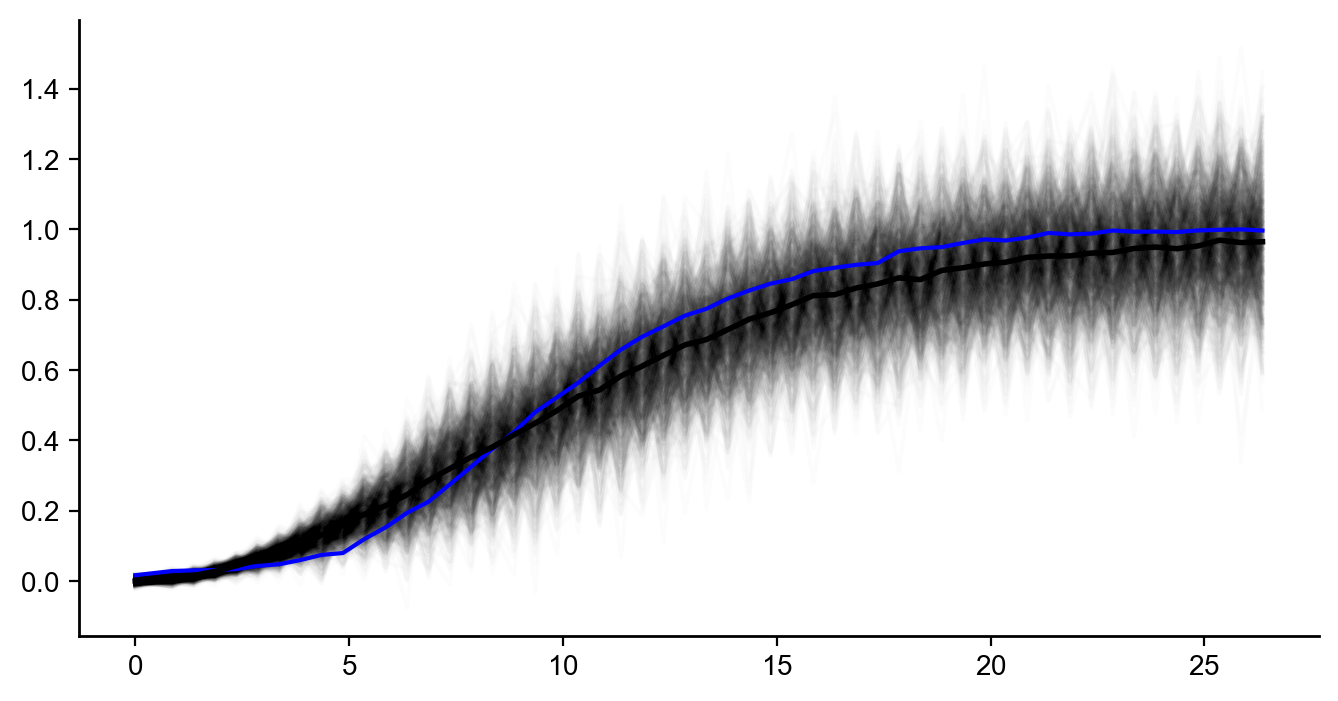

In [242]:
fig, ax = plt.subplots(1,1, figsize=(8,4))
predictions = linear_trace.posterior_predictive['cyto_like'][0,:,:,0]
for i in range(predictions.shape[0]):
        # print(predictions)
        ax.plot(cyto_times, predictions[i,:], 'k', alpha=0.01)
ax.plot(cyto_times, cyto_data, 'b')
ax.plot(cyto_times, np.mean(predictions, axis=0), 'k', linewidth=2)

array([<Axes: >], dtype=object)

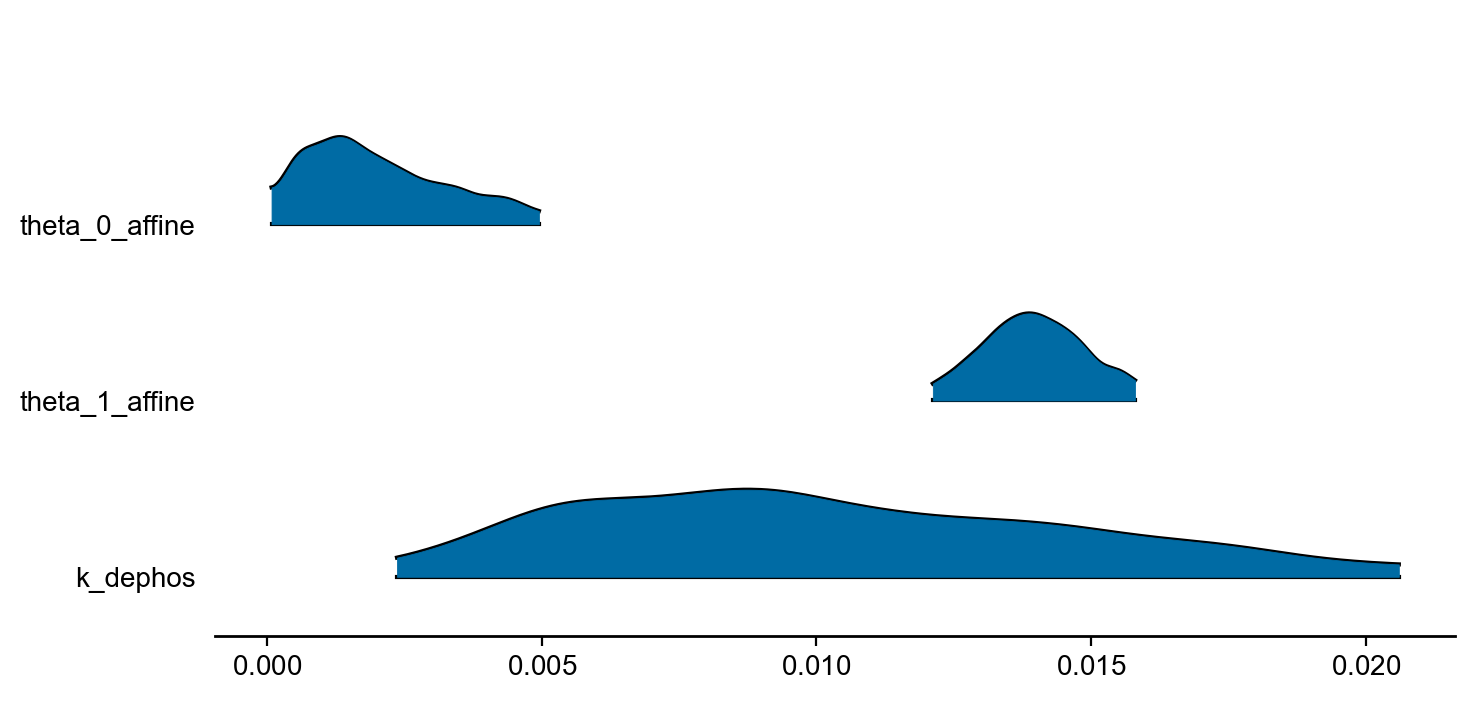

In [247]:
az.plot_forest(linear_trace, var_names=['theta_0_affine', 'theta_1_affine', 'k_dephos'], combined=True, figsize=(8,4),
               kind='ridgeplot')

array([[<Axes: ylabel='theta_0_affine'>, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta_1_affine'>, <Axes: >, <Axes: >],
       [<Axes: xlabel='theta_0_affine', ylabel='k_dephos'>,
        <Axes: xlabel='theta_1_affine'>, <Axes: xlabel='k_dephos'>]],
      dtype=object)

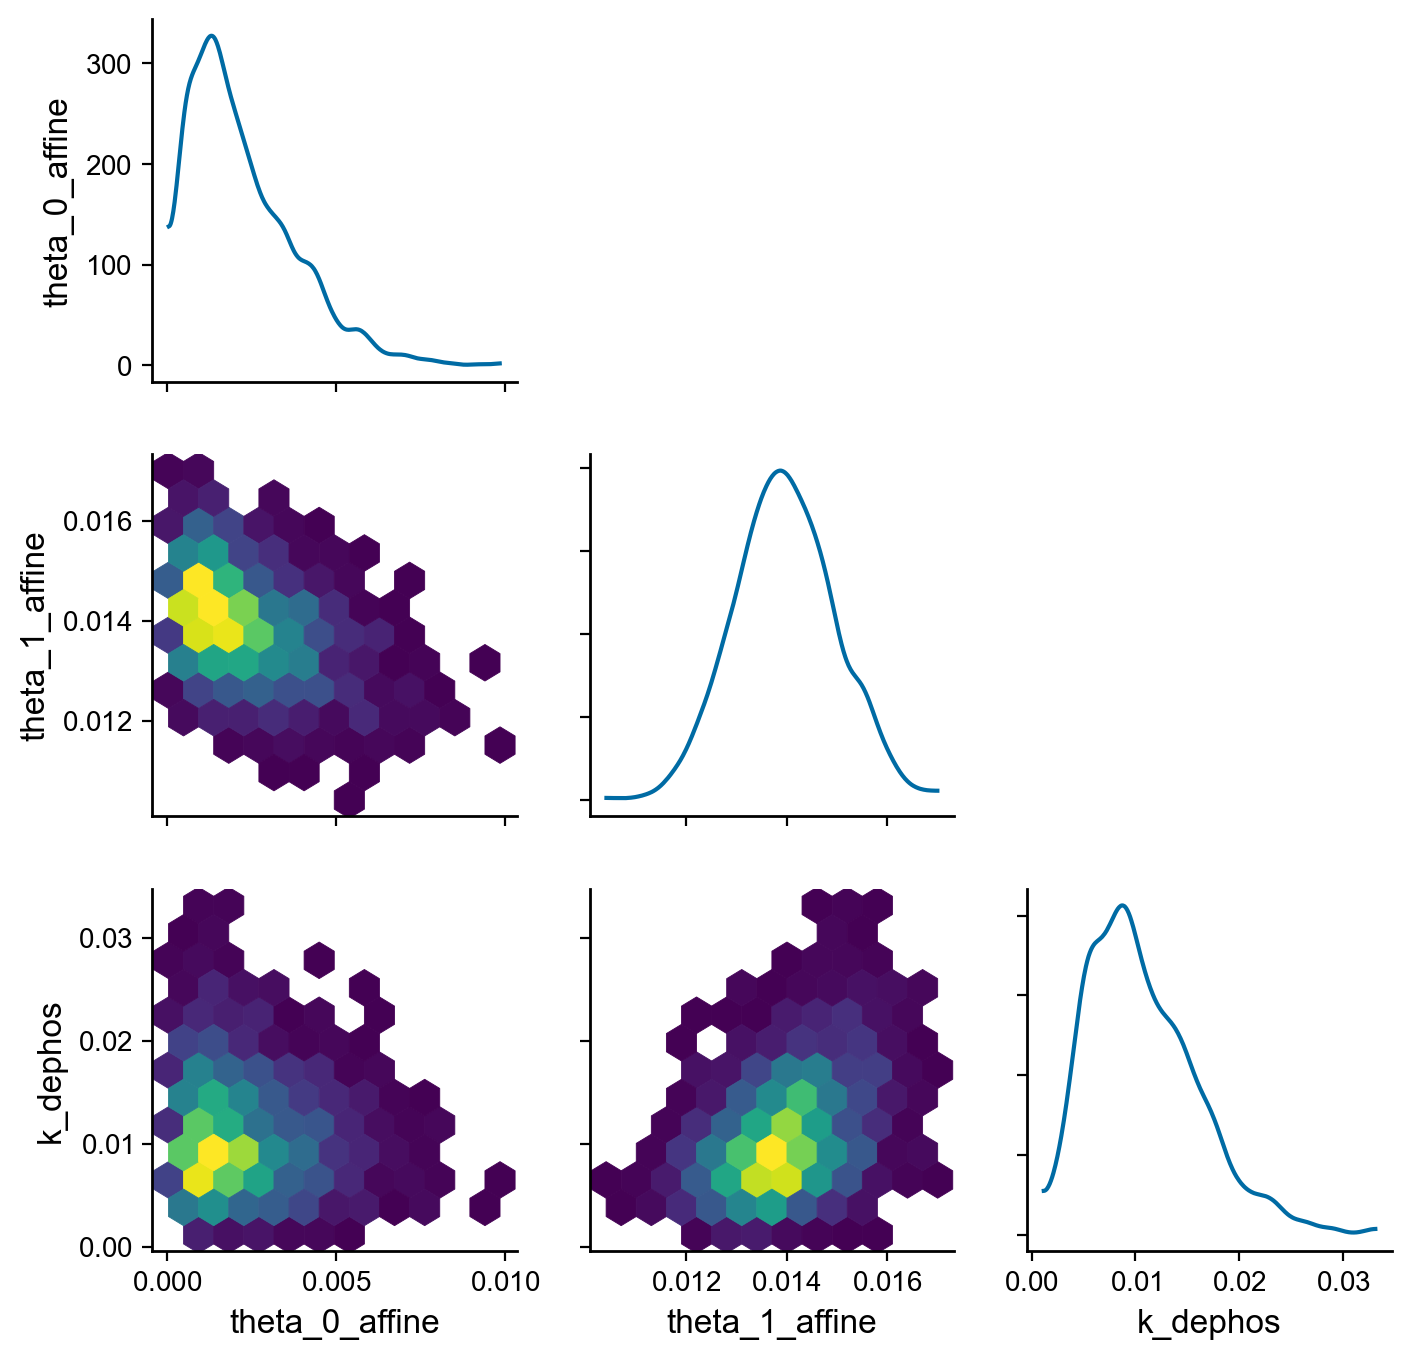

In [250]:
az.plot_pair(linear_trace, var_names=['theta_0_affine', 'theta_1_affine', 'k_dephos'], figsize=(8,8),
             kind="hexbin",
    marginals=True,)

#### Extra - Exploration of sampling with Jax and Nutpie

In [182]:
try:
    with linear_sensor_model:
        linear_trace_jax_grad_def = sample_numpyro_nuts(1000, tune=1000, chains=2, jitter=False,
                                        chain_method='vectorized', random_seed=seed)
except:
    print('Failed to sample with NumPyro')

Compiling...
Compilation time = 0:00:00.084629
Sampling...
sample: 100%|██████████| 2000/2000 [00:08<00:00, 227.00it/s]
Sampling time = 0:00:09.025946
Transforming variables...
Transformation time = 0:00:00.238528


Explore sampling with the jax-able sampler. Will define a model that has slightly different pytensor ops w/o defining the grads since we will just use jax for the grads.

In [169]:
class SolOp_noGrad(Op):
    def __init__(self, sol_op_jax_jitted):
        self.sol_op_jax_jitted = sol_op_jax_jitted

    def make_node(self, *inputs):
        # Convert our inputs to symbolic variables
        inputs = [pt.as_tensor_variable(inp) for inp in inputs]
        # Assume the output to always be a float64 matrix
        outputs = [pt.matrix()]
        return Apply(self, inputs, outputs)

    def perform(self, node, inputs, outputs):
        result = self.sol_op_jax_jitted(*inputs)
        outputs[0][0] = np.asarray(result, dtype="float64")
        
    def grad(self, inputs, output_grads):
        raise NotImplementedError("PyTensor gradient of Op not implemented")
    
sol_op_noGrad = SolOp_noGrad(sol_op_jax_jitted)

# register the ops with PyTensor
@jax_funcify.register(SolOp_noGrad)
def sol_op_jax_funcify_noGrad(op, **kwargs):
    return sol_op_jax

test_model = pm.Model()
with test_model:
    # priors
    theta_1_linear = pm.LogNormal('theta_1_linear', mu = -4.0, sigma=1.5)
    k_dephos = pm.LogNormal('k_dephos', mu = -2.0, sigma=1.0)
    # sigma = pm.LogNormal('sigma', mu = -2.0, sigma=0.75)
    
    prediction = pm.Deterministic('pred', sol_op_noGrad(theta_1_linear, k_dephos))

    # likelihood
    cyto_like = pm.Normal('cyto_like', mu=prediction, sigma=cyto_std*std_mult, observed=cyto_data)

Now try sampling with Numpyro NUTS

In [183]:
with test_model:
    trace = sample_numpyro_nuts(1000, tune=1000, chains=2, chain_method='vectorized',
                                jitter=False, random_seed=seed)  
                                # nuts_kwargs={'init_strategy':'init_to_mean'})

Compiling...
Compilation time = 0:00:00.092756
Sampling...
sample: 100%|██████████| 2000/2000 [00:08<00:00, 235.01it/s]
Sampling time = 0:00:08.533200
Transforming variables...
Transformation time = 0:00:00.231938


Now try with Nutpie sampler

In [188]:
nutpie_compiled_model = nutpie.compile_pymc_model(linear_sensor_model)
trace_nutpie = nutpie.sample(nutpie_compiled_model, draws=1000, tune=1000, chains=2, cores=1, seed=seed)

/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/pytensor/link/numba/dispatch/basic.py:373: UserWarning: Numba will use object mode to run SolOp's perform method
  warnings.warn(
/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/pytensor/link/numba/dispatch/basic.py:373: UserWarning: Numba will use object mode to run VJPSolOp's perform method
  warnings.warn(
/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/pytensor/link/numba/dispatch/basic.py:373: UserWarning: Numba will use object mode to run SolOp's perform method
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.96,3
,2000,0,0.94,3
